# Risk-Neutral Valuation and Numerical Methods

## Load the Libs we need

In [1]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt

# Importing specific modules and functions
from scipy.linalg import solve


### Risk-Neutral Valuation Principles for Options Pricing

#### Simulating Price Paths

In [2]:
def mb_simulate_price_paths(S0, r, sigma, T, N, M, seed=None):
    """Simulate risk-neutral geometric Brownian motion price paths."""
    if seed is not None:
        np.random.seed(seed)

    dt = T / N
    price_paths = np.zeros((N + 1, M))
    price_paths[0] = S0

    for t in range(1, N + 1):
        z = np.random.standard_normal(M)
        price_paths[t] = price_paths[t - 1] * np.exp(
            (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z
        )

    return price_paths


#### Pricing a Binary Option

In [3]:
def mb_price_binary_option(S0, K, r, sigma, T, N, M, option_type="call", seed=None):
    """Price a cash-or-nothing binary option by Monte Carlo simulation."""
    price_paths = mb_simulate_price_paths(S0, r, sigma, T, N, M, seed=seed)

    if option_type == "call":
        payoff = np.where(price_paths[-1] > K, 1.0, 0.0)
    elif option_type == "put":
        payoff = np.where(price_paths[-1] < K, 1.0, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    binary_price = np.exp(-r * T) * np.mean(payoff)
    return binary_price


# Example usage with a fixed seed
S0 = 100
K = 105
r = 0.05
sigma = 0.20
T = 1
N = 252
M = 10000
seed = 42

binary_call_option_price = mb_price_binary_option(
    S0, K, r, sigma, T, N, M, option_type="call", seed=seed
)
binary_put_option_price = mb_price_binary_option(
    S0, K, r, sigma, T, N, M, option_type="put", seed=seed
)

print(f"The price of the binary call option is: ${binary_call_option_price:.4f}")
print(f"The price of the binary put option is: ${binary_put_option_price:.4f}")


The price of the binary call option is: $0.4371
The price of the binary put option is: $0.5141


#### Pricing a Barrier Option

In [4]:
def mb_price_barrier_option(
    S0, K, B, r, sigma, T, N, M, option_type="call", barrier_type="up-and-out", seed=None
):
    """Price a simple knock-out barrier option by Monte Carlo simulation."""
    price_paths = mb_simulate_price_paths(S0, r, sigma, T, N, M, seed=seed)

    if barrier_type == "up-and-out":
        alive = np.all(price_paths <= B, axis=0)
    elif barrier_type == "down-and-out":
        alive = np.all(price_paths >= B, axis=0)
    else:
        raise ValueError("barrier_type must be 'up-and-out' or 'down-and-out'")

    terminal_prices = price_paths[-1]

    if option_type == "call":
        intrinsic = np.maximum(terminal_prices - K, 0.0)
    elif option_type == "put":
        intrinsic = np.maximum(K - terminal_prices, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    payoff = np.where(alive, intrinsic, 0.0)
    barrier_price = np.exp(-r * T) * np.mean(payoff)
    return barrier_price


# Example usage with a fixed seed
S0 = 100
K = 105
B_up = 110
B_down = 90
r = 0.05
sigma = 0.20
T = 1
N = 252
M = 10000
seed = 42

barrier_call_option_price = mb_price_barrier_option(
    S0, K, B_up, r, sigma, T, N, M,
    option_type="call", barrier_type="up-and-out", seed=seed
)

barrier_put_option_price = mb_price_barrier_option(
    S0, K, B_down, r, sigma, T, N, M,
    option_type="put", barrier_type="down-and-out", seed=seed
)

print(f"The price of the up-and-out barrier call option is: ${barrier_call_option_price:.4f}")
print(f"The price of the down-and-out barrier put option is: ${barrier_put_option_price:.4f}")


The price of the up-and-out barrier call option is: $0.0253
The price of the down-and-out barrier put option is: $0.5498


#### Visualizing a Sample of Simulated Paths

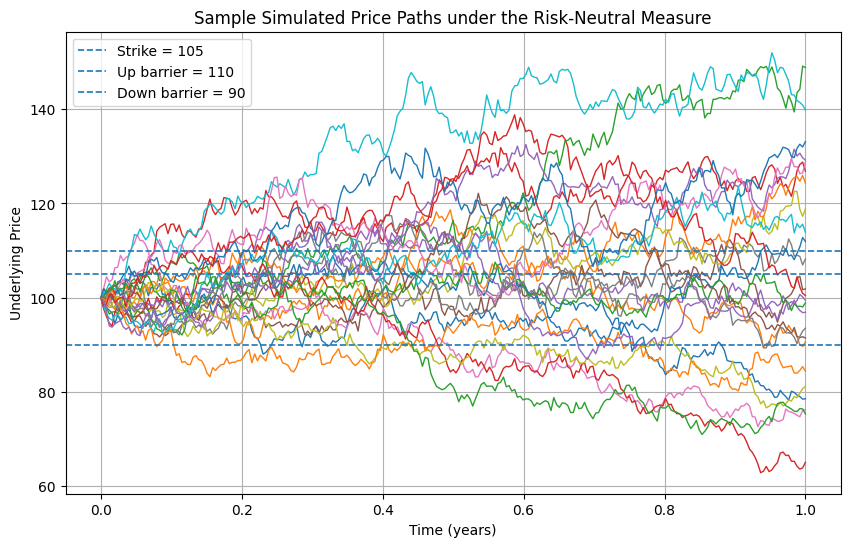

In [5]:
# Plot a small sample of simulated paths to visualize the strike and barrier levels
sample_paths = mb_simulate_price_paths(S0=100, r=0.05, sigma=0.20, T=1, N=252, M=25, seed=42)
time_grid = np.linspace(0, 1, sample_paths.shape[0])

plt.figure(figsize=(10, 6))
for i in range(sample_paths.shape[1]):
    plt.plot(time_grid, sample_paths[:, i], linewidth=1)

plt.axhline(105, linestyle="--", linewidth=1.2, label="Strike = 105")
plt.axhline(110, linestyle="--", linewidth=1.2, label="Up barrier = 110")
plt.axhline(90, linestyle="--", linewidth=1.2, label="Down barrier = 90")
plt.xlabel("Time (years)")
plt.ylabel("Underlying Price")
plt.title("Sample Simulated Price Paths under the Risk-Neutral Measure")
plt.legend()
plt.grid(True)
plt.show()


## Implementing numerical methods for options pricing in Python

#### Constructing the Crank-Nicolson Scheme

In [6]:
def mb_price_european_option_crank_nicolson(
    S_max, K, r, sigma, T, N_S, N_T, option_type="call"
):
    """Price a European option with a basic Crank-Nicolson finite-difference scheme."""
    dt = T / N_T
    ds = S_max / N_S
    grid_S = np.linspace(0, S_max, N_S + 1)

    A = np.zeros((N_S - 1, N_S - 1))
    B = np.zeros((N_S - 1, N_S - 1))

    for i in range(1, N_S):
        alpha = 0.25 * dt * (sigma**2 * i**2 - r * i)
        beta = -0.5 * dt * (sigma**2 * i**2 + r)
        gamma = 0.25 * dt * (sigma**2 * i**2 + r * i)

        j = i - 1
        A[j, j] = 1 - beta
        B[j, j] = 1 + beta

        if i > 1:
            A[j, j - 1] = -alpha
            B[j, j - 1] = alpha
        if i < N_S - 1:
            A[j, j + 1] = -gamma
            B[j, j + 1] = gamma

    if option_type == "call":
        V = np.maximum(grid_S - K, 0.0)
    elif option_type == "put":
        V = np.maximum(K - grid_S, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    V_inner = V[1:-1].copy()

    for n in range(N_T):
        tau_now = n * dt
        tau_next = (n + 1) * dt

        if option_type == "call":
            left_now, left_next = 0.0, 0.0
            right_now = S_max - K * np.exp(-r * tau_now)
            right_next = S_max - K * np.exp(-r * tau_next)
        else:
            left_now = K * np.exp(-r * tau_now)
            left_next = K * np.exp(-r * tau_next)
            right_now, right_next = 0.0, 0.0

        boundary = np.zeros(N_S - 1)
        alpha_1 = 0.25 * dt * (sigma**2 * 1**2 - r * 1)
        gamma_M = 0.25 * dt * (sigma**2 * (N_S - 1)**2 + r * (N_S - 1))

        boundary[0] += alpha_1 * (left_now + left_next)
        boundary[-1] += gamma_M * (right_now + right_next)

        rhs = B @ V_inner + boundary
        V_inner = solve(A, rhs)

    V_full = np.zeros_like(grid_S)
    V_full[1:-1] = V_inner

    if option_type == "call":
        V_full[0] = 0.0
        V_full[-1] = S_max - K * np.exp(-r * T)
    else:
        V_full[0] = K * np.exp(-r * T)
        V_full[-1] = 0.0

    return grid_S, V_full


# Parameters
S_max = 300
K = 145
r = 0.05
sigma = 0.20
T = 1
N_S = 100
N_T = 1000

grid_S, V_call = mb_price_european_option_crank_nicolson(
    S_max, K, r, sigma, T, N_S, N_T, option_type="call"
)
_, V_put = mb_price_european_option_crank_nicolson(
    S_max, K, r, sigma, T, N_S, N_T, option_type="put"
)

# Option prices at S = 150
call_option_price = np.interp(150, grid_S, V_call)
put_option_price = np.interp(150, grid_S, V_put)

print(f"The European call option price is: ${call_option_price:.2f}")
print(f"The European put option price is: ${put_option_price:.2f}")


The European call option price is: $18.49
The European put option price is: $6.42


#### Visualizing the Crank-Nicolson Option Value Curves

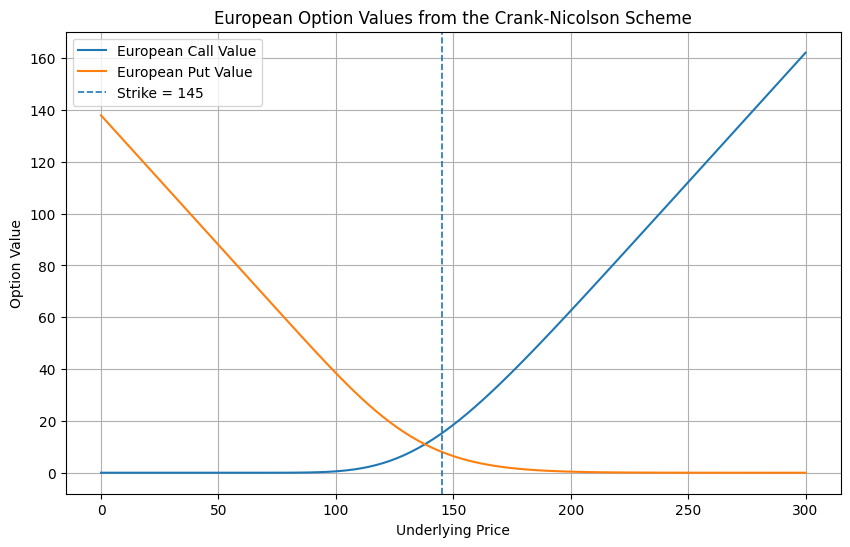

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(grid_S, V_call, label="European Call Value")
plt.plot(grid_S, V_put, label="European Put Value")
plt.axvline(145, linestyle="--", linewidth=1.2, label="Strike = 145")
plt.xlabel("Underlying Price")
plt.ylabel("Option Value")
plt.title("European Option Values from the Crank-Nicolson Scheme")
plt.legend()
plt.grid(True)
plt.show()
